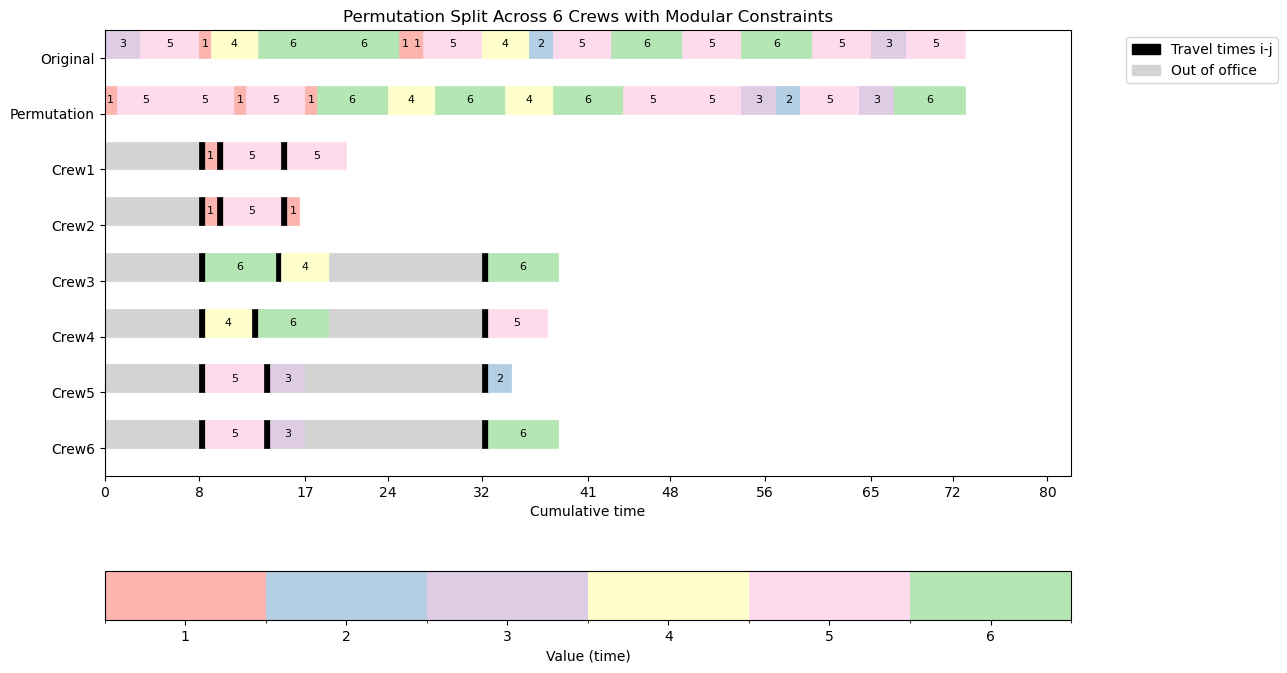

In [6]:
import random
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import matplotlib.patches as mpatches

# -----------------------------
# 1. Parameters and data
# -----------------------------
xticks = [0, 8, 17, 24, 32, 41, 48, 56, 65, 72, 80]

# 18 values (6 crews × 3 values)
nums = [random.randint(1, 6) for _ in range(18)]

# permutation
perm = nums.copy()
random.shuffle(perm)

# split into 6 crews (3 values each)
crew1 = perm[0:3]
crew2 = perm[3:6]
crew3 = perm[6:9]
crew4 = perm[9:12]
crew5 = perm[12:15]
crew6 = perm[15:18]

# -----------------------------
# 2. Custom colormap
# -----------------------------
base = plt.get_cmap('Pastel1', 6)
colors = [base(i) for i in range(6)]
colors[-1] = (0.7, 0.9, 0.7, 1.0)  # value 6 = light green

cmap = mcolors.ListedColormap(colors)

bounds = np.arange(1, 8) - 0.5
norm = mcolors.BoundaryNorm(bounds, cmap.N)

# -----------------------------
# 3. Plot setup
# -----------------------------
fig, ax = plt.subplots(figsize=(13, 7))

# -----------------------------
# 4. Draw reference rows
# -----------------------------
def draw_row(values, y):
    x = 0
    for v in values:
        ax.add_patch(plt.Rectangle((x, y), v, 1,
                                   color=cmap(v-1),
                                   #edgecolor='black',
                                   linewidth=0.5))
        ax.text(x + v/2, y + 0.5, str(v),
                ha='center', va='center', fontsize=8)
        x += v
    return x

# -----------------------------
# 5. Crew drawing
# -----------------------------
def draw_crew(values, y, start_x=8):
    # initial out-of-office (0 → 8)
    ax.add_patch(plt.Rectangle((0, y), 8, 1,
                               color='lightgray',
                               #edgecolor='black',
                               linewidth=0.5))

    x = start_x

    for i, v in enumerate(values):
        # travel time (black spacer)
        ax.add_patch(plt.Rectangle((x, y), 0.5, 1,
                                   color='black',
                                   #edgecolor='black',
                                   linewidth=0.5))
        x += 0.5

        # value block
        ax.add_patch(plt.Rectangle((x, y), v, 1,
                                   color=cmap(v-1),
                                   #edgecolor='black',
                                   linewidth=0.5))

        ax.text(x + v/2, y + 0.5, str(v),
                ha='center', va='center', fontsize=8)

        x += v

        # modular interruption (only if not last value)
        if i < len(values) - 1 and (x % 24) >= 17:
            delta = (8 - (x % 24)) % 24
            if delta > 0:
                ax.add_patch(plt.Rectangle((x, y), delta, 1,
                                           color='lightgray',
                                           #edgecolor='black',
                                           linewidth=0.5))
                x += delta

    return x


# -----------------------------
# 6. Draw all rows
# -----------------------------
w1 = draw_row(nums, 7)
w2 = draw_row(perm, 5)

w3 = draw_crew(crew1, 3)
w4 = draw_crew(crew2, 1)
w5 = draw_crew(crew3, -1)
w6 = draw_crew(crew4, -3)
w7 = draw_crew(crew5, -5)
w8 = draw_crew(crew6, -7)

max_width = max(w1, w2, w3, w4, w5, w6, w7, w8)

# -----------------------------
# 7. Colorbar (bottom)
# -----------------------------
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = plt.colorbar(sm,
                    ax=ax,
                    orientation='horizontal',
                    pad=0.15,
                    ticks=range(1,7))

cbar.set_label("Value (time)")

# -----------------------------
# 8. Legend (outside right)
# -----------------------------
black_patch = mpatches.Patch(color='black',
                             label='Travel times i-j')

gray_patch = mpatches.Patch(color='lightgray',
                            label='Out of office')

ax.legend(handles=[black_patch, gray_patch],
          bbox_to_anchor=(1.05, 1),
          loc='upper left')

# -----------------------------
# 9. Axes
# -----------------------------
ax.set_xticks(xticks)
ax.set_xlim(0, max(max_width + 2, 82))

ax.set_ylim(-8, 8)

ax.set_yticks([7, 5, 3, 1, -1, -3, -5, -7])
ax.set_yticklabels([
    "Original",
    "Permutation",
    "Crew1",
    "Crew2",
    "Crew3",
    "Crew4",
    "Crew5",
    "Crew6"
])

ax.set_xlabel("Cumulative time")
ax.set_title("Permutation Split Across 6 Crews with Modular Constraints")

# -----------------------------
# 10. Show
# -----------------------------
plt.tight_layout()
plt.show()